# Notebook 01: SU(2) Group Theory

**Learning objectives:**
- Understand the Cayley-Klein (quaternion) parameterization of SU(2)
- Verify fundamental group properties: closure, associativity, identity, inverse
- Compute traces and determinants of SU(2) matrices

**Prerequisites:** Notebook 00 (setup)

**Key functions:** `su2.hstart()`, `cstart()`, `mult()`, `dag()`, `tr()`, `det()`

In [1]:
from notebook_utils import setup_paths
setup_paths()

import numpy as np
import matplotlib.pyplot as plt
import su2

/home/zeke/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. The Cayley-Klein Parameterization

Every SU(2) matrix can be written as
$$U = a_0 \mathbb{1} + i\,(a_1 \sigma_1 + a_2 \sigma_2 + a_3 \sigma_3)$$
with the constraint $a_0^2 + a_1^2 + a_2^2 + a_3^2 = 1$
(the unit 3-sphere $S^3$).

In code we store just the **four real numbers** $[a_0, a_1, a_2, a_3]$.
The identity is $[1, 0, 0, 0]$.

This form is the SU(2) instance of the general Lie-group exponential $g = \exp(i\theta^a T^a)$ with the spin-1/2 generators $T^a = \sigma^a/2$ obeying $[\sigma^a,\sigma^b]=2i\varepsilon^{abc}\sigma^c$. See High Energy Physics Essentials §6.1.4 for unitary groups generally.

In [2]:
# Identity element
I = su2.cstart()
print(f"Identity: {I}")
print(f"det(I)  = {su2.det(I):.10f}")
print(f"Tr(I)   = {su2.tr(I):.10f}")

Identity: [1. 0. 0. 0.]
det(I)  = 1.0000000000
Tr(I)   = 2.0000000000


In [3]:
# Random SU(2) element ("hot start")
U = su2.hstart()
print(f"Random U: {U}")
print(f"det(U)  = {su2.det(U):.10f}  (should be 1)")
print(f"|U|^2   = {np.sum(U**2):.10f}  (same thing)")

Random U: [-0.43437258  0.55483657  0.69107869 -0.16089465]
det(U)  = 1.0000000000  (should be 1)
|U|^2   = 1.0000000000  (same thing)


### Quaternion vs. matrix form

Throughout this code, `U` is stored as a quaternion 4-vector `[a0, a1, a2, a3]`
(we sometimes call this the **Q representation**). The function `su2.showU(U)` reconstructs
the full $2\times 2$ complex matrix so we can do standard linear algebra with it.

The code below displays the quaternion and matrix forms side by side, then
demonstrates two important points:

- **Matrix addition is not group multiplication.** Adding two SU(2) matrices
  does *not* produce another SU(2) matrix — the determinant is no longer 1.
- **Unitarity.** The defining property $U U^\dagger = \mathbb{1}$ can be checked
  directly in the matrix representation.

In [4]:
# Display the 2x2 matrix form
U_mat = su2.showU(U)
print("Q representation (quaternion 4-vector):")
print(f"  U = {U}")
print()
print("Matrix representation (2x2 complex):")
print(U_mat)
print()

print("U_mat + U_mat (matrix addition, NOT in SU(2)):")
print(U_mat + U_mat)
print(f"  det = {np.linalg.det(U_mat + U_mat):.4f}  (not 1 => not in SU(2))")
print()

print("U @ U† (should be identity):")
UUdag = U_mat @ np.conj(U_mat).T
print(UUdag)
print(f"  max deviation from I: {np.max(np.abs(UUdag - np.eye(2))):.2e}")

Q representation (quaternion 4-vector):
  U = [-0.43437258  0.55483657  0.69107869 -0.16089465]

Matrix representation (2x2 complex):
[[-0.43437258-0.16089465j  0.69107869+0.55483657j]
 [-0.69107869+0.55483657j -0.43437258+0.16089465j]]

U_mat + U_mat (matrix addition, NOT in SU(2)):
[[-0.86874516-0.3217893j   1.38215738+1.10967314j]
 [-1.38215738+1.10967314j -0.86874516+0.3217893j ]]
  det = 4.0000-0.0000j  (not 1 => not in SU(2))

U @ U† (should be identity):
[[ 1.00000000e+00+0.00000000e+00j -1.44442071e-17+2.77555756e-17j]
 [-1.44442071e-17-2.77555756e-17j  1.00000000e+00+0.00000000e+00j]]
  max deviation from I: 3.13e-17


## 2. Group Properties

SU(2) is a **Lie group**: a continuous group with smooth multiplication.
Let's verify the four group axioms.

The four axioms — closure, identity, inverse, associativity — and the distinction between Abelian and non-Abelian groups are stated in High Energy Physics Essentials §6.1.1. The Lie-group structure of SU(N) (continuous, finite parameter count) is discussed in §6.1.5.

### 2a. Closure: $U_1 \cdot U_2 \in$ SU(2)

In [5]:
U1 = su2.hstart()
U2 = su2.hstart()
U12 = su2.mult(U1, U2)

print(f"det(U1*U2) = {su2.det(U12):.10f}")
assert abs(su2.det(U12) - 1.0) < 1e-10
print("Closure verified!")

det(U1*U2) = 1.0000000000
Closure verified!


### 2b. Associativity: $(U_1 U_2) U_3 = U_1 (U_2 U_3)$

In [6]:
U3 = su2.hstart()
lhs = su2.mult(su2.mult(U1, U2), U3)
rhs = su2.mult(U1, su2.mult(U2, U3))

diff = np.max(np.abs(lhs - rhs))
print(f"|(U1*U2)*U3 - U1*(U2*U3)| = {diff:.2e}")
assert diff < 1e-12
print("Associativity verified!")

|(U1*U2)*U3 - U1*(U2*U3)| = 2.78e-17
Associativity verified!


### 2c. Identity: $U \cdot \mathbb{1} = U$

In [7]:
UI = su2.mult(U1, su2.cstart())
diff = np.max(np.abs(UI - U1))
print(f"|U*I - U| = {diff:.2e}")
assert diff < 1e-12
print("Identity element verified!")

|U*I - U| = 0.00e+00
Identity element verified!


### 2d. Inverse: $U \cdot U^\dagger = \mathbb{1}$

For SU(2), the inverse is the **Hermitian conjugate** (dagger).
In the quaternion representation: $U^\dagger = [a_0, -a_1, -a_2, -a_3]$.

The defining unitarity relation $U^\dagger U = \mathbb{1}$ for U(N) (and hence SU(N)) is discussed in High Energy Physics Essentials Ch. 6.

In [8]:
U1_dag = su2.dag(U1)
product = su2.mult(U1, U1_dag)

print(f"U * U^dag = {product}")
print(f"Tr(U*U^dag) = {su2.tr(product):.10f}  (should be 2)")
diff = np.max(np.abs(product - su2.cstart()))
assert diff < 1e-10
print("Inverse property verified!")

U * U^dag = [1. 0. 0. 0.]
Tr(U*U^dag) = 2.0000000000  (should be 2)
Inverse property verified!


## 3. Quaternion Multiplication

The `mult` function implements quaternion multiplication:
$$c_0 = a_0 b_0 - \mathbf{a} \cdot \mathbf{b}$$
$$\mathbf{c} = b_0 \mathbf{a} + a_0 \mathbf{b} - \mathbf{a} \times \mathbf{b}$$

This is equivalent to $2 \times 2$ matrix multiplication but uses only
real arithmetic -- much faster than complex matrix ops.

The identification of SU(2) with the unit 3-sphere $S^3 = \{(a_0,a_1,a_2,a_3) : a_0^2 + \mathbf{a}^2 = 1\}$ underlies this parameterization (see Creutz Ch. 11, Eq. 8.26).

**What are quaternions?** Quaternions are a number system that extends the complex
numbers — instead of one imaginary unit $i$, there are three: $i, j, k$ satisfying
$i^2 = j^2 = k^2 = ijk = -1$. A quaternion is $q = a_0 + a_1 i + a_2 j + a_3 k$.

The key insight for lattice QCD: **unit quaternions** (those with $|q| = 1$) are
in one-to-one correspondence with SU(2) matrices. This is why we can store each
gauge link as just 4 real numbers.

For more background, see: [Quaternion — MathWorld](https://mathworld.wolfram.com/Quaternion.html)

In [9]:
# The trace Tr(U) = 2*a_0 -- only depends on the real part
U = su2.hstart()
print(f"U = {U}")
print(f"Tr(U) = {su2.tr(U):.6f}")
print(f"2*a_0 = {2*U[0]:.6f}")
assert abs(su2.tr(U) - 2*U[0]) < 1e-12

U = [ 0.95412077 -0.28780334 -0.02382661 -0.07908908]
Tr(U) = 1.908242
2*a_0 = 1.908242


## 4. Distribution of Random Matrices

`hstart()` generates uniformly-distributed SU(2) matrices (Haar measure).
Let's sample many and look at the trace distribution.

The Haar (invariant) measure on SU(2) takes the simple form $d\mu(g) = \pi^{-2}\,d^4a\,\delta(a^2-1)$ — the uniform surface measure on $S^3$ (Creutz Ch. 11, Eq. 8.27).

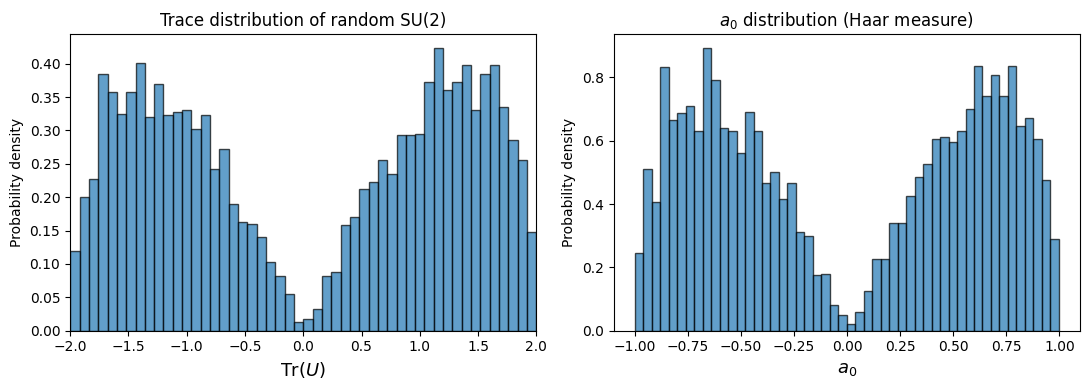

det check: max|det - 1| = 3.33e-16
All determinants are exactly 1 (by construction: det = a0^2+a1^2+a2^2+a3^2)


In [10]:
# TRY: Change N to 500 or 50000 — larger samples give smoother distributions
# TRY: Compare traces vs a_0 — they're related by Tr(U) = 2*a_0
N = 5000
traces = np.array([su2.tr(su2.hstart()) for _ in range(N)])
dets   = np.array([su2.det(su2.hstart()) for _ in range(N)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(traces, bins=50, density=True, alpha=0.7, edgecolor='k')
ax1.set_xlabel(r"$\mathrm{Tr}(U)$", fontsize=13)
ax1.set_ylabel("Probability density")
ax1.set_title("Trace distribution of random SU(2)")
ax1.set_xlim(-2, 2)

# a_0 component distribution (more informative than det which is always 1)
a0_vals = np.array([su2.hstart()[0] for _ in range(N)])
ax2.hist(a0_vals, bins=50, density=True, alpha=0.7, edgecolor='k')
ax2.set_xlabel(r"$a_0$", fontsize=13)
ax2.set_ylabel("Probability density")
ax2.set_title(r"$a_0$ distribution (Haar measure)")

plt.tight_layout()
plt.show()

print(f"det check: max|det - 1| = {np.max(np.abs(dets - 1)):.2e}")
print(f"All determinants are exactly 1 (by construction: det = a0^2+a1^2+a2^2+a3^2)")

The trace distribution is not flat: it follows
$P(\text{Tr}) \propto \sqrt{1 - (\text{Tr}/2)^2}$
(the Wigner semicircle law for SU(2)).
More weight near $\text{Tr} = 0$ means most random matrices
are "far" from the identity.

## Note: Configuration File Naming Convention

Throughout these notebooks you will encounter saved gauge configurations with names like:
```
config_L6x6x6T20_b2.40_cold_0350.pkl
```
The naming convention is: `config_L{Ls}x{Ls}x{Ls}T{Lt}_b{beta}_{start}_{sweep}.pkl`

- `L6x6x6T20` — spatial size $6^3$, temporal extent $T = 20$
- `b2.40` — the coupling constant $\beta = 2.40$
- `cold` or `hot` — whether the simulation started from an ordered or random configuration
- `0350` — the **sweep count** (how many Monte Carlo updates have been performed), NOT a timestamp


## Exercises

1. Generate 1000 random SU(2) matrices and histogram their $a_0$ component.
   Compare to the expected distribution.
2. Verify that $\det(U_1 U_2) = \det(U_1) \det(U_2)$ for random $U_1, U_2$.
3. Compute $U^n$ for $n = 1 \ldots 20$ and plot $\text{Tr}(U^n)$.
   What periodic behavior do you see?
4. **Eigenvalue exploration**: Generate 500 random SU(2) matrices and
   reconstruct each as a $2\times 2$ complex matrix
   $U = a_0 I + i(a_1 \sigma_1 + a_2 \sigma_2 + a_3 \sigma_3)$.
   Compute eigenvalues with `np.linalg.eigvals`.
   Plot them in the complex plane — verify they lie on the unit circle
   and come in conjugate pairs $e^{\pm i\theta}$.
5. **Exponential map**: Given a unit vector $\hat{n}$ and angle $\theta$,
   the SU(2) element $U = \cos(\theta/2)\,I + i\sin(\theta/2)\,(\hat{n}\cdot\vec\sigma)$
   has quaternion representation $[\cos(\theta/2),\; \sin(\theta/2)\hat{n}]$.
   Generate $U$ for $\theta = 0, \pi/4, \pi/2, \pi$ with $\hat{n} = (0,0,1)$.
   Verify $\det(U) = 1$ and $\mathrm{Tr}(U) = 2\cos(\theta/2)$.
6. **Center elements**: The center $Z_2 = \{I, -I\}$ consists of SU(2)
   matrices that commute with every other SU(2) matrix.
   Generate 100 random $U$ and verify that $[I, U] = [(-I), U] = 0$
   but $[\tilde{U}, U] \neq 0$ for generic $\tilde{U}$.
   (*Hint:* $-I$ in quaternion form is $[-1, 0, 0, 0]$.)
7. **Error handling**: Copy the `try/except` import check from Notebook 00
   (cell 2) and run it here. Try deliberately misspelling a package name —
   what happens?
8. **Wrong dimensions**: Try running `su2.mult(U1, np.array([1, 0, 0]))`
   (a 3-element vector instead of 4). What error do you get? Why?
